In [ ]:
!pip -q install -U \
    langchain-google-genai \
    langchain-core \
    pydantic \
    pillow \
    pytesseract

In [ ]:
!apt-get -qq update
!apt-get -qq install -y tesseract-ocr

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import os
import json
import base64

from getpass import getpass
from PIL import Image
import pytesseract

from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass(
        "Enter your Gemini API key: "
    )
#AQ.Ab8RN6LCaVXPqsecx6yBSHZnoVn4fKZHdDkX-F7MlIJnVT6tzQ
print("Gemini API key loaded.")


Enter your Gemini API key: ··········
Gemini API key loaded.


In [ ]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

print("Gemini model ready.")

Gemini model ready.


In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Uploaded file:", image_path)

Saving invoice.png to invoice (4).png
Uploaded file: invoice (4).png


Image size: (492, 601)


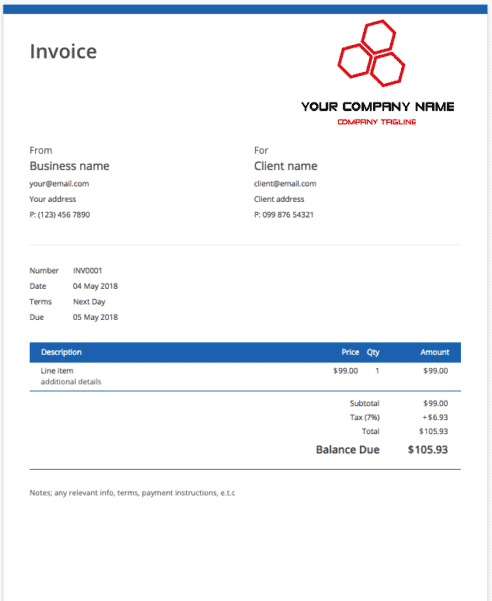

In [ ]:
image = Image.open(image_path)

print("Image size:", image.size)
display(image)

In [ ]:
with open(image_path, "rb") as f:
    image_bytes = f.read()
#base64 encoding
image_base64 = base64.b64encode(image_bytes).decode("utf-8")

print("Image converted to Base64.")

Image converted to Base64.


In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Describe everything important you can see in this invoice."
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the image provided, here are all the key details shown in this invoice template:\n\n### **1. Header & Branding**\n* **Document Title:** Invoice\n* **Logo:** Red hexagonal geometric logo on the top right\n* **Company Name Placeholder:** YOUR COMPANY NAME / COMPANY TAGLINE\n\n---\n\n### **2. Sender Details ("From")**\n* **Name:** Business name\n* **Email:** `your@email.com`\n* **Address:** Your address\n* **Phone:** (123) 456 7890\n\n---\n\n### **3. Recipient Details ("For")**\n* **Name:** Client name\n* **Email:** `client@email.com`\n* **Address:** Client address\n* **Phone:** 099 876 54321\n\n---\n\n### **4. Invoice Details**\n* **Invoice Number:** `INV0001`\n* **Invoice Date:** `04 May 2018`\n* **Payment Terms:** `Next Day`\n* **Due Date:** `05 May 2018`\n\n---\n\n### **5. Items & Pricing**\n| Description | Price | Qty | Amount |\n| :--- | :--- | :--- | :--- |\n| Line item<br>*additional details* | $99.00 | 1 | $99.00 |\n\n---\n\n### **6. Financial 

In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "What is the vendor name?"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'The vendor name on the invoice is **Invoice Fly.** (represented by **Albert Sort**).', 'extras': {'signature': 'EqcICqQIARFNMg+ortuBKJXIbinf9JAEePeDset10GkvaUKY9YLpL+3cppc7utBQ4G5uCZkk0klmkHm7L07poShkt1CQfZRW7WADEGTOiFzhi3VQhVBin35Xh8Ub7J4Jul/IJZaBf3ZCGdeEZ79FOz1g9Zsoith9/NPmWDU+08ozmIn3xHsOZzSPRofGDsa8VCn6oFt0woiIupGqcc/l4+PTnLd97vOCKY3FZ+tZPp5gkGBo4E+g2rzl1Oa3OflOj4h3heRA4AWSy4OdqEIEFZHwNNvXoWsqOBJiVEOq44vyLXgATx+GSjsxI6v6U5GdcVLVDz4lnIgXmJGrUMgyGXcgGF2DKIByN6Rxajfa/P5ho1N2CvRKc8sxT5CHi2Lgj72XX9zOBJHqIPQuwQoWIjkO3C96LjCLU5OQ0TwqsyiKRuImJqrbyJjWLvnzybmVdzKwtS2oS0gqScJx4V14Q76eEQKDAL5GULMiaotuThHZjPvBRQWUpVzrxJGgdOJjArDBjm6Rp+tgjtJLhAltJCj61hXyig3zHFtvFIp9rXAKVvSDrNaUNEB04Sdp0VoBBKaKAQ7id/IvtjQZXz+iRKfQogKGz6DNGXJNskHq5L4mJkPALCNmC/L9dvJX2XOU86iborCP+p0i7WJd+m5g/mFqTJtfg3Ju3Ic5vfx2gHthmp7rdSi0n2Cw0MXO26eTZAVzTncBTZI7SixN/MIhP6JlzLKAIAan02bPcqKEBJ5D3NSUcbSUwOR+smDX1KRBGBHOUNFddGAjnluwPpBn2yjEnxWl0qyUIdzCUwP4G1OXq6HhOZuF/+9paseWO4JpVit3oUJuGI01HgA5CUz4X2q+CgLvn

In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "What is the invoice number?"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'The invoice number is **1234** (listed as "NO. 1234" in the top-right box).', 'extras': {'signature': 'EtkECtYEARFNMg9kIAhPo3yl4g67G9IaPb/9wApjHThPsqdTdSROT/uJDvKkbjDMguND9WAawbwAMGBeT70nFMaIyKxlyp24oGjJbvOZLITOdz98e8f8GCK/gVG/jd4opM/MbA5hR7GAucASGHxAWbwgLYhKLoE6Ni4wl8tIA+NSjB4/HVeE68hcTsyQdugV30Kkn+YGCv0nIn6fo2UawFjmgMgpixhRvAmx2YgVS8viceBd1c6edAtcQHfImIvIHQDj4c1bJpc5Fb54EOJ6osL5XXRQjiADHOPH5jik5zJzzBGS6HVg0xv7rGap6ic5Ojh9tZhnX67crNFMH363hsVog1VbesHRmR4i8QxW/Z9Xbh5VYEbG28QRgL89EU+ESymb4uCKSS2r/gGnliSRK8UEHyqLsz9BlNqZYXCUR0+ctCg1W76zNEH0NdSGFs+TY7Z6UHWqtVIJIo0ykedBz4cjw1WU2HfvVAt3gB5HAJciBoWoC/nEneRMQqeLGErgRqwyqgQFE66R/1a2Z3UrpieTZB07AJTOcYIcqs/W+Y3p70BJPZcn6a4Kw0Ni4TRWq9s2mRoU2xe0HMjwBeYgecNFnNphHxQVPMUOG42FeW9+Hs5Wb3bqeLZAxVVzyfFrdXkASJ3n+8/ndcgnxOxCejS7Lj1pLrlS255MsNhROix3Wt4i8JEjF2cGmpx1L9zK17jLtcLaCuajt8mLMnvfrr+8swGf/KuRUCIdIlbBjTkBAmnJ9RsyLNQa9+YhEKepgqemuQoJ61Bw/DEd3b+N8hTsDhj11PMbaoO7Ng=='}}]


In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "What is the final invoice total?"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the invoice, the final invoice total (**TOTAL AMOUNT**) and the **BALANCE DUE** are both **$1512**. \n\nHere is the summary breakdown:\n* **Sub Total:** $1,250\n* **Tax (21%):** $262\n* **Total Amount / Balance Due:** **$1,512**', 'extras': {'signature': 'ErYECrMEARFNMg8DZ2ThsNCeIXU9mpl3V0U8p0vaatjCYDGD6NlGbnUv5/VQy/hf6SiS1zIW82A739YoAwp65h/JrwbkrhGGAk/bS7l6sOXEWNfF+rL+2nuLr7/LvUVWSoTcgBfwgN6SiFdi087aoRfnCjURMhGeUeh/KYT+ZouVeAhRWJlMwInO7xxOH3rg3LO1RCH3GHw81e51DRFVF6d4GvmoMbPobs6qz0Xjv7b19RpHnE1zEzKtmj26pseslX0umLvPtPSYOUbmh7pb229xT2L2fcz3PMoJ6Pnr8vuSwNA/MKbZXmG8SKf4OPcaVHaMnTCXPQa+MIiCyfnDACWsI5c8PynA5TvnOWX1DJLpZOVNCfPI+A4bPs5un3yXListcXzEqcJdlZh+B3s88jnyqTzivfSfp/6i9vjJRiyoHKfkyprDh7dlwOI+0KXts81dnFjFdqQsurG3R8rNOuzXxItT2ichWJ83i7wcGkLan/j6LJqPTjwKTsVWL8zc9iCpf5G7lCMUEAe+2Fnio2eT80EMf2apUsHDzi9u/GOxOrNwEcL3O8soQALdGbNjrBuPXo+li6h3ELhF//LNgkYRrYTOH+WdOwHxXDoaeKR1SSzzoTSkXoG19OI/H8HkJMoDOAU3rC+regda6b6YhvyZbmYqiJqdonpwdsMf2Wb9DV6iW5qnrzRjDThZvTsw/4uI

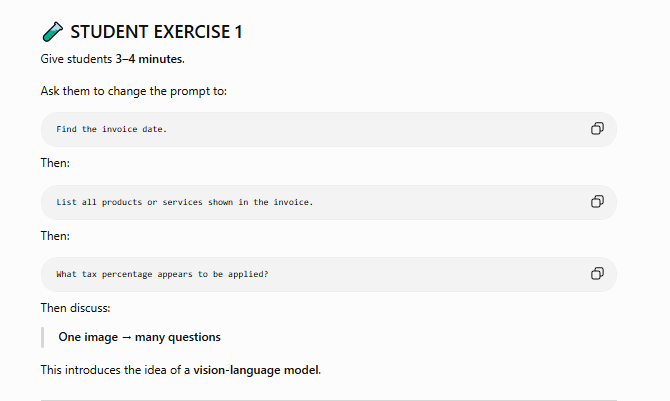

In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Find the invoice date"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'The invoice date is **1/01/2036** (located in the top right box under the invoice number).', 'extras': {'signature': 'Eq4FCqsFARFNMg9ocMw0t+A02t+fIUebg+9eVCJLQS4Oxv24070FcvdSCZplAD7Z/EG5M3ooUG8gIoUdl5fVLmBpYAkvB8IOrSezQwswjhQKZOh/cBAQvKIY6L1JbtctmbYLSaFAmK5HZ/ywTTLEBVbCypV5BxVcfZX+VrAc2QPfUgTNOW9d2sOW369qqA3qiXztAgyGJ7ydVjzSS/Ft7zQdmT8ssBdnBaD7QaRbAt98lRdySYiYP1eAaRmlA/Y9lLLh0P2WByHRHY6zOZPJ30ZaLL4IApf42teTEiaXU7bMlGfcTN6PVPZfAAQuT6oq+KlRohV1nOlS53wFCPBavRAUaRRCrItMBH0vtjWtgI+1SkSpzQjPLzZPfgljQd9YuOc0mo0OQTzHZSTK7hnQgjfVs9Nl9UInZDe/fcNTJSj+n/g9q3B4/HK0Ty/7nXTv4dsufqfxS1cwrNrF+tjCTHaRMiloH4e7jpmDZbdOmi+ntvcM01oNgEfeJcH3tikRhbL8joNbhSi4h6MMlm4TOkVVb736FPRY/gUazlv3Evnec4QUR2uvZ3dcYbs0HF+k4s7DmErr6LtCxbijkNtf/GAwPEmhW+plBx/kvc7D+q/eo/Gzm/hRb/XqkVe0A1KJ8RPf3AIASDzz20CZWKa7eZKiOeeV3IOGKz/6cj++O6igfLTF/GboQVDRSpX3ZFTX/DvUJywsbr1wzz5HQbTz1ywWIHoUuUcw0z8daZCt1TIL8UZZAOpHSq7zG6Tsa8ByntrwZ0Vt7QqazpvOCoeZ41ujzlPA4esVRVoNQTv2fkvUFRAvql4zbAKSIxoVBJbD/9KG3e3FFhJPm574R4wT4XI

In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "List all products or services shown in invoice"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the provided invoice, the products/services listed under the **Description** column are:\n\n1. **Item 1** (Quantity: 2 | Price: $100 | Total: $200)\n2. **Item 2** (Quantity: 1 | Price: $150 | Total: $150)\n3. **Item 3** (Quantity: 2 | Price: $300 | Total: $600)\n4. **Item 4** (Quantity: 1 | Price: $300 | Total: $300)', 'extras': {'signature': 'EtkDCtYDARFNMg/lKXFiYA05A/7vEYUyXGdZbUQOPGoq9Oo3b/E6rTD5ae6NmFWKU1wpFkqGytLbxZ0fGtLPsEfLxmsTmK/Ole0QDlwhmDH5sR+WmpOcNpB4nentSt5Xx1BCEacSA6+WrtJhgnT0+zYd8Vrlz3pY6ilAoOeS4TZAknDOLw+J5a9nPyJhLSLqnJ8meQvd9sXhNdN6dQVgnH4N9L0XsC1DPS9XNK/kBCTqt9USCXLne7EJWwZtrqXK1lJGs/DGRmL+rD/fmcsYnLf45JpGm+rIEqbB9EM1e0Bnw2KADy24SMyDXUzDGtPzq6qHCUM6PFCwQygCEgArBgS4tgwuG0K0nXhuch2F7oc9ph/HZfJuu688mjGWR2+A0fQ41KR4aXIy3houxw800b6psdaJKOfFunKlemF//JuHeg6wI99JoOpoR5zl091NfVdWU8hERxyxIz/ztJC48d4WAjma0NrnUoQHlXsIfNNSuyRdNiAFGB5Mm2PZj3i1crTW8tbnt7tsYrs219iVMwruSU/XtUh3j8eG3no4A6llce9skehaQ6nfsMyQG4dAVBWwyuSWJz4BRCuKNEjZQtSzrmfIsYcdJuO3qI1mPu

In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "What tax percentage appears to be applied?"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the invoice, a **21%** tax percentage appears to be applied (labeled as `TAX (21%)` under the subtotal).', 'extras': {'signature': 'EugHCuUHARFNMg/Yrl9GP6H0s+PQbm1GKqG5Ts5weM9w3aZEh2QLeSyQgAWcozc6M1pvgDTCqZmwhG0b1IdmYOZHRlkiCBWgcqCLfU8UyxCc2JFoJwaHYztIt2jx3hbQHyz8BV5iTy6a3xYnUfgipoQQu+IBxAo2aazYks7CVE8MaH9b3Y1Txe+byRoe3LvDUkijUCLCBGan791lNO16lPVgDGyEja90Ef9WvWEDYki8p94YN05KmSjyjb02kz+zBV2MRuCeP7OP6dc+mpPhu0dN6G5HZ57TDf8B7ZDYvOriwyUI9O86rf/WlYgyebcOnjNXNlYZi1/ojSXYkRNYMI6CCLceB82+QqFh3IG2ijhAaUmKvNDCM0SW82yAYHAUAmNEiP7V/wYT8ts6yxOaJ4b2sqaZMd+/3jIzREt7zrBUQKoSg4Gym7pkzaoJ8Jol2SPWzcGBAsZwLoUbO0GMqilFZC1b8GtY5G7EyfrHRhhKjqsYsZ3Um8z8s+yx/lEi1WcbViNoYCUKiVtb2Vq25mf0gX0LHrN7QJNvpJu97KnTrFsi1Ylq3lUXT+SC7A98Sx9tLejaHlEIKeDuASI+xFGNk7SccMG833vDr+nRgiAxR8pF6lDUhNRuHAEh+JQzyLASUnwDioBdR058eS7pbZCcFoJ3ujNfqP+ZSejFLKmQtowwDh8Z5INVjUo6xZiaa9ROFa0KrK6E3t56Djs9aPEe0kqEPsmjJG18SmRZP4CjqyLgfDYmD1btXQ3bu/M0QZM4D/GVRLxnsLCXwgO21iwIYqU0TzBFxz4MIMgluG9iciQqUwyugNcSDlUxJsLb

BAD PROMPT


In [ ]:
bad_prompt = """
Extract information from this invoice.
"""

message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": bad_prompt
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Here is the extracted information from the invoice:\n\n---\n\n### **Invoice Header**\n* **Invoice Number:** 1234\n* **Invoice Date:** 1/01/2036\n* **Due Date:** *(Not specified)*\n* **P.O. Number:** *(Not specified)*\n* **Payment Terms:** Please pay within 30 days.\n\n---\n\n### **Sender Information (Invoice Fly)**\n* **Contact Name:** Albert Sort\n* **Address:** 5740, N. Sheridan Road, Chicago, IL-60660\n* **Email:** Albert@invoicefly.com\n* **Phone:** 123-456-789\n\n---\n\n### **Bill To**\n* **Name:** Sam Altman\n* **Address:** Fifth Avenue New York, 10029\n* **Email:** sam@sam.com\n* **Phone:** 987-654-321\n\n---\n\n### **Ship To**\n* **Name:** Client Name\n* **Address:** Client Street, City, State, Zip Code\n* **Email:** Client email\n* **Phone:** Phone number\n\n---\n\n### **Line Items**\n\n| Description | Quantity | Price | Total |\n| :--- | :---: | :---: | :---: |\n| Item 1 | 2 | $100 | $200 |\n| Item 2 | 1 | $150 | $150 |\n| Item 3 | 2 | $300 | $600 |

In [ ]:
good_prompt = """
You are an invoice extraction assistant.

Analyze the invoice carefully.

Extract:

1. Vendor name
2. Invoice number
3. Invoice date
4. Subtotal
5. Tax
6. Discount
7. Final total

Rules:
- Do not invent information.
- If a value is not visible, say "Not available".
- Preserve numbers accurately.
- Clearly separate each field.
"""

message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": good_prompt
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the invoice provided, here are the extracted details:\n\n1. **Vendor Name:** Invoice Fly\n2. **Invoice Number:** 1234\n3. **Invoice Date:** 1/01/2036\n4. **Subtotal:** $1250\n5. **Tax:** $262\n6. **Discount:** $0\n7. **Final Total:** $1512', 'extras': {'signature': 'EssJCsgJARFNMg9EWWWbmRmlah0HXl+wF/rAH3m3ogdNu2qShJd/ppp72knK9K7+PhsDWESsY1JnwblTT+D9j50yrpPOLSkezGrmaq6wCPPArQuA5xXx8P+7Vu6CeOU5yNNVhj3vvcrfclactz2i/Sek+VxqSMbr7s2AU5burT1Gl9eciYQH7ULMyXfq7/COENyla7edej7At6kWEoPaKaS+ZjlawvuPTV5ph2nuYoFIsF/bNDnLcTkYK2mV9T9tcwPOko78vxQtsDr9U5TN7VcyhcsSqKsWb4cuoMA7EbI2chb0vPZ7Lzygcurtc8+oA/Pb6/FtG41dhURMH5OLnyIpAAZ6F4Z7J4Bonw6IzgwuvB/24RFAWJiOpIkdpH2aQQ3AC4VvagUI1rtNMxq0qxeGcrUFLR6qjLkRpfSG7ztBGDQ/DpPXTurfsOtlsoSjTvDScpPkBsGVkN5tGRgtqoLpi3DU7ern23Mq2a7fHrMMBiOBE+KUBPGILDLORJqFcRoTnxhJ4odoWW7LwLhznphD7QGeH0de6XjHvSMa2JX3wnSiv6Z6proC9qctOmDKQQBhruGWugRHmRr0X1sKKDvndVVvlV8C5GdVfqtISMvZB0OgRuIW+h7Eb0M0mnPxTSBktEIG/7PIyr4/+YVkgOokYFJWXamwoOKflyih6ShU7NbHuXxgRZchh

In [ ]:
good_prompt = """
You are an invoice extraction assistant.

Analyze the invoice carefully.

Extract:

1. Vendor name
2. Invoice number
3. Invoice date
4. Subtotal
5. Tax
6. Discount
7. Final total
8.Customer Name
9.Payment Terms
10. Due date

Rules:
- Do not invent information.
- If a value is not visible, say "Not available".
- Preserve numbers accurately.
- Clearly separate each field.
"""

message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": good_prompt
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Here are the extracted details from the invoice:\n\n1. **Vendor Name:** Invoice Fly.\n2. **Invoice Number:** 1234\n3. **Invoice Date:** 1/01/2036\n4. **Subtotal:** $1250\n5. **Tax:** $262\n6. **Discount:** $0\n7. **Final Total:** $1512\n8. **Customer Name:** SAM ALTMAN\n9. **Payment Terms:** Please pay within 30 days.\n10. **Due Date:** Not available', 'extras': {'signature': 'EssMCsgMARFNMg//BQer/m8OqXzwcZ/mHy2dinmhLKAtn4595qcUDlcbH80713oHm57HwT7paDm5lMC5lxcZPQVQ7OMavpbkNkGQ99jrbzeiPDjgYYdCaaqkNvlqI3gF870JgCyBsYXN/JuFiv/luLbQ0w+SPvccJxyZJGlfbgo5XS2FXoYn/hQdKemO0ixA1qx9Lm4lprxbjRdurKFMh/42j0BapLBlMbblcFguWotHsz+3QCRHv58/bdfMubgBPjOPWWxpRCpZ38nr1R5y3GAqq0aH49RFsSyqcaev065iQETGmsMjRC0kO1s9h2ytkIfzNoegSFrjq+I5oLAecpm7k3z9ADEUEkSmH84Y1giBmFkofpjn4nnoLK2v0ecOHYyPQmT9qGpZPsgt5/9b8NjuuinS25NzvWldOL5XhBTfnG85BpQoVo0FmLWia173JMElFZpcWYIATpUJp/M8NncVUFsETuG3Nla+0KwcGdl7nYltRKGpIhzJ/NZTGRBTxnU5bfZ1GzXb5iOa3L2IPcKLZR7CyDXNQczvriADDIOwPkJpPkg4t/Pr5oJOlovD11N9DxaLR0rlumkiO

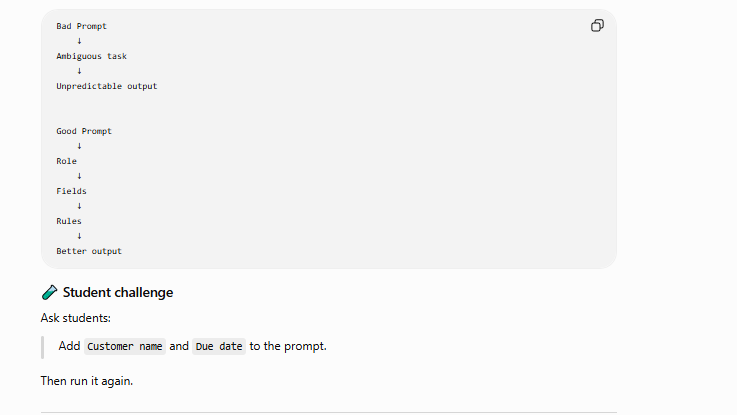

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded:", image_path)

Saving invoice.png to invoice (1).png
Uploaded: invoice (1).png


Image size: (595, 842)
Image mode: RGB


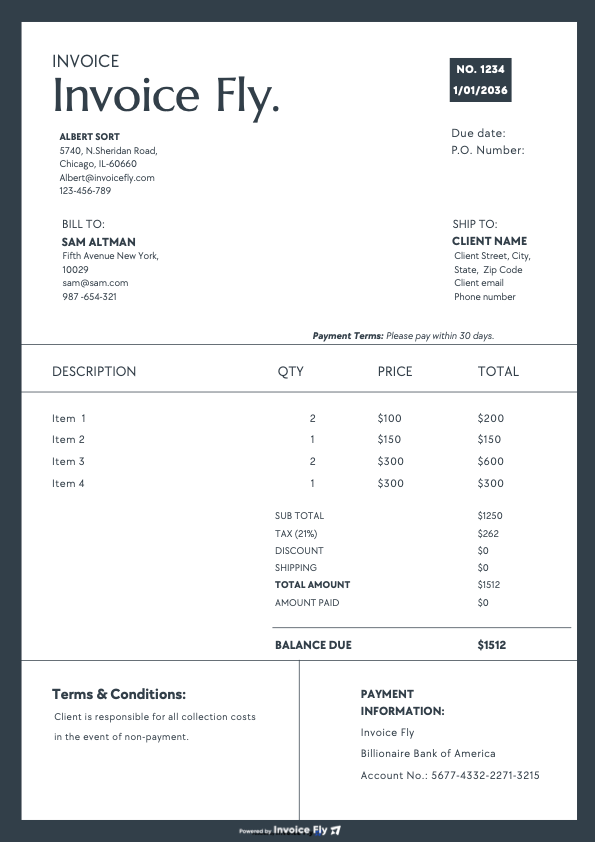

In [ ]:
from PIL import Image

image = Image.open(image_path).convert("RGB")

print("Image size:", image.size)
print("Image mode:", image.mode)

display(image)

In [ ]:
import pytesseract

ocr_text = pytesseract.image_to_string(
    image,
    lang="eng",
    # config="--psm 6"
)

print("Characters:", len(ocr_text))
print("Lines:", len(ocr_text.splitlines()))

print("\n========== OCR RESULT ==========\n")
print(ocr_text)

Characters: 705
Lines: 54

========== OCR RESULT ==========

INVOICE —_
Invoice Fly.

uber soRT Due date:
5740, N Sheridan Road, P.O. Number:
Chicago, L-60660

‘bers@invoicey.com

125-456-789

BILLTO: SHIP TO:

SAM ALTMAN ‘CLIENT NAME
Fifth Avenue New Yor

10029
sam@samcom

987 -654521

Cent Street, City
State, Zip Code
Cent ema
Phone number

Payment Terms: Pease pay within 30 days

DESCRIPTION ay PRICE TOTAL

$100 $200
$150 $150
$300 $600
$300 $300

sus TOTAL $1250
TAX (eI) see2
DIscOUNT so
SHIPPING so
‘TOTAL AMOUNT

AMOUNTPAID so

BALANCE DUE

Terms & Conditions: PAYMENT.
Client is responsible forall collection costs INFORMATION:
Inthe event of non-payment. Invoice Fly
Billionaire Bank of America

Account No.: 5677-4852-2271-8215

eens ty Ivolce Fly $7




File: invoice (1).png
Exists: True
Format: PNG
Size: (595, 842)
Mode: P


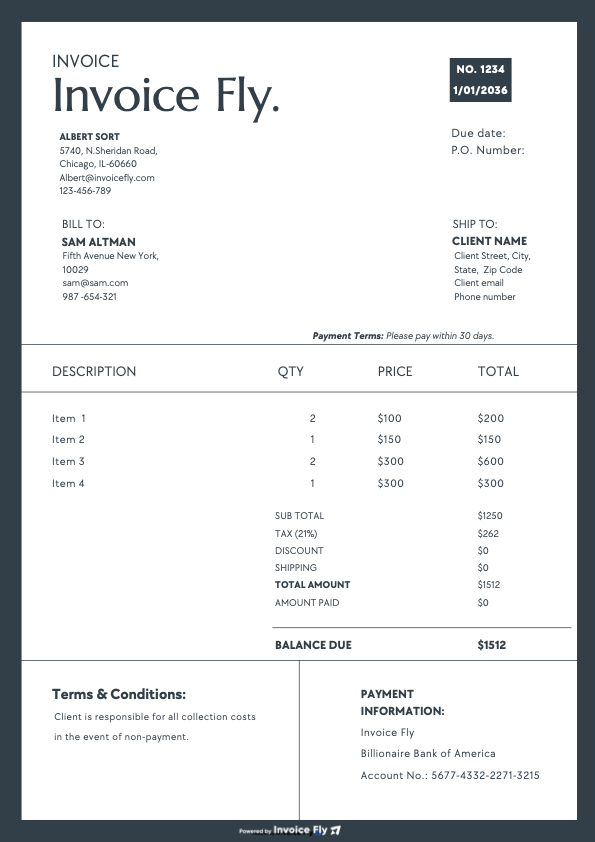

In [ ]:
from PIL import Image
import os

print("File:", image_path)
print("Exists:", os.path.exists(image_path))

image = Image.open(image_path)

print("Format:", image.format)
print("Size:", image.size)
print("Mode:", image.mode)

display(image)

In [ ]:
import pytesseract

print("Testing OCR...")

text = pytesseract.image_to_string(
    image,
    lang="eng",
    config="--psm 6"
)

print("Characters detected:", len(text))
print("Lines detected:", len(text.splitlines()))

print("\n========== OCR RESULT ==========\n")
print(repr(text))
print("\n================================")

Testing OCR...
Characters detected: 753
Lines detected: 32

========== OCR RESULT ==========

'INVOICE Teen\nInvoice Fly _\nALBERT SORT Due date:\n‘5740, N Sheridan Road, P.O. Number:\nChicago, I-60660\nAlbers@involcefy.com\n123-456-789\nBILL TO: SHIP TO:\n‘SAM ALTMAN ‘CLIENT NAME\nFifth Avenue New York (Cent Steet, City,\n10029 State, Zip Code\nsam@sam.com Cent email\n987-654-321 Phone number\nPayment Terms: Please pay within 30 days\nDESCRIPTION ry PRICE TOTAL\ntem 1 2 $100 $200\nItem 2 1 $150 $150\nItem 3 2 $300 $600\ntem 4 1 $300 $300\nsua TOTAL 120\nTAK (21%) $262\nDISCOUNT $0\nSHIPPING $0\n‘TOTAL AMOUNT sisiz\n[AMOUNT PAID $0\nBALANCE DUE $1512\nTerms & Conditions: PAYMENT.\nClient is responsible forall collection costs INFORMATION:\nInthe event of non-payment. Invoice Fly\nBillionaire Bank of America\n‘Account No.: 5677-4332-2271-3215\nronenses Invotce Fly 57\n'



In [ ]:
keywords = [
    "invoice",
    "total",
    "tax",
    "subtotal",
    "date"
]

for keyword in keywords:
    if keyword.lower() in ocr_text.lower():
        print(f"{keyword}: FOUND")
    else:
        print(f"{keyword}: NOT FOUND")

invoice: FOUND
total: FOUND
tax: FOUND
subtotal: NOT FOUND
date: FOUND


In [ ]:
ocr_prompt = f"""
You are an invoice understanding assistant.

Below is OCR text extracted from an invoice.

Identify:

- Vendor
- Invoice number
- Invoice date
- Subtotal
- Tax
- Discount
- Total

Do not invent missing information.

OCR TEXT:
{ocr_text}
"""

response = llm.invoke(ocr_prompt)

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the provided OCR text, here are the extracted details:\n\n* **Vendor:** Invoice Fly\n* **Invoice number:** Not specified\n* **Invoice date:** Not specified\n* **Subtotal:** $1250\n* **Tax:** see2 *(OCR garbled text: `TAX (eI) see2`)*\n* **Discount:** $0 *(from `DIscOUNT so`)*\n* **Total:** Not specified *(value missing next to `TOTAL AMOUNT`)*', 'extras': {'signature': 'EtYjCtMjARFNMg+QZrcNrYm5bvatR69NGfmuzgRsZqchgjbQKDQkSi7cdPC5ROSIoxk4T1xW92Lb6NBK7nYI7+KN+gbw13jDPeXyTqQ8xcUgzl52Br8PgUdmIgz3I5Ozi5z+pe41pcQQfbMxg6DVOuEOFMZAMqQR/UhkozBGzU7HkD8wVFcWEcSLTZ0LkrSkUVSZsuTzUFZN/6yJygz9Z2qo4WYGT7lcLQ28MpFQyTRTP+IwJqzkxuEAetFW+9YsGZzb53aA+ZTjsR+ASWDOHo1CulCqy2KEIkBRs1d7VWUoiku5msaB8sMZuSoZ8iOvUbaA0r/nfiYIWZNjBTI5Q09sF0E31eY7GiNcgZWGL8ATuSgri9Y+QcqaN0eXcoU46tY6Zdmb61nAeQ1RF/LkkqGZvMu0yuv+3r++yW0YErn5dcPyMzKaZ4wvskRU3Ca9n4pe1fXkhPd+0KSLxZTsVC4uU+y6w4ylwPWznCqLOLeoCjDao9eKhUwJ5Y7PyW229ZOgwCB+J/v7XkUBRCZdfF9LEr1dCk4RVwi1Fahdf2O31dYfPxEp3xRLF+dSHOKsZpLw/jBwMmLQ9qw

In [ ]:
def calculate_total(subtotal, tax, discount):
    return subtotal + tax - discount

In [ ]:
result = calculate_total(
    subtotal=1000,
    tax=180,
    discount=50
)

print("Final total:", result)

Final total: 1130


In [ ]:
@tool
def calculate_invoice_total(
    subtotal: float,
    tax: float,
    discount: float = 0
) -> float:
    """Calculate final invoice total."""

    return subtotal + tax - discount

In [ ]:
print("Tool name:", calculate_invoice_total.name)
print("Description:", calculate_invoice_total.description)

Tool name: calculate_invoice_total
Description: Calculate final invoice total.


In [ ]:
result = calculate_invoice_total.invoke({
    "subtotal": 1000,
    "tax": 180,
    "discount": 50
})

print("Tool result:", result)

Tool result: 1130.0


In [ ]:
llm_with_tools = llm.bind_tools(
    [calculate_invoice_total]
)

In [ ]:
response = llm_with_tools.invoke(
    "Calculate an invoice total where subtotal is 5000, tax is 900 and discount is 200."
)

print("Text:")
print(response.content)

print("\nTool calls:")
print(response.tool_calls)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Text:
[]

Tool calls:
[{'name': 'calculate_invoice_total', 'args': {'discount': 200, 'subtotal': 5000, 'tax': 900}, 'id': 'call_2823882', 'type': 'tool_call'}]


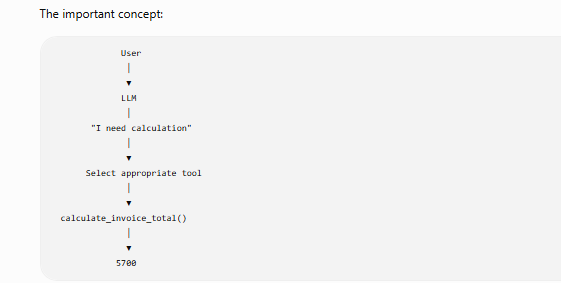

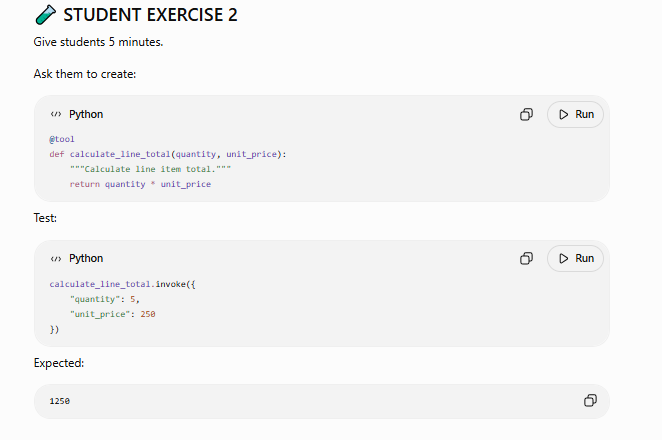

In [ ]:
response = llm.invoke(
    f"""
    Extract the vendor, invoice number,
    subtotal, tax and total from this OCR text.

    OCR:
    {ocr_text}
    """
)

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Here is the extracted information based on the provided OCR text:\n\n* **Vendor:** Invoice Fly\n* **Invoice Number:** Not specified (appears garbled/missing as "uber soRT")\n* **Subtotal:** $1250\n* **Tax:** Garbled in OCR (`TAX (eI) see2`)\n* **Total:** Not specified / Missing in OCR text (listed only as `TOTAL AMOUNT`)', 'extras': {'signature': 'Eu4pCuspARFNMg944oTEt+ZLR5iQ5sLCgxtggIEbresI+x2gL9z6FnDs70gVOPpgHO/6/hZh8nNnd859plLNbDfDPtQnlGPW58mSJcO8VTNEPnUvtT+YU+sdHCLFZD42QkSHS/mn9QkJlDSSTaUCYaVTkGD5yyZYDHS2XiM4CFgiuoHAiDgW9Gm9bx9xQ9/0ih1NMfiRGk7LTtF+Q5u8GmTd+gJmPBPcVOEdp1VDUFzHc8hlW2ybVBb8N8HhND5Rnp6qxvjRAS5jr5GBeCSt4T0oxYSNUeguRoIT81oioc8EKy97+/YWjGMqVgiG37CPNdh/egPHNgKJjJ7nybcSYMi0Y1Kdn+T1MHHVa1qoKOHJCjQ6FqE5oN8+Xm94LGFu4R4eZXxlyqCmGoxBGE36IvHCqYA+QtpOV2lJ64vOsF/5gQZy7yCQ4quzTHCji/l+PL9Onh6HDGvBSfcyKKPAMjqemmYg15h8N+Kt92W3tZneMB2p4yMUZZ4CZYXHGLqYqX1vr6lefUXsNTC2JpT9etw/Ma43ykcgblkEcRdLH+IaUbqQs1Rwwu6SnGL5UkHQK5E+3/gWBf2oe5S9XWmAZexTqXO9mbzEPgKtN2T1bydxAIM

In [ ]:
#pytantic basemodel superclass
class Invoice(BaseModel):
    vendor: str | None = None
    invoice_number: str | None = None
    invoice_date: str | None = None
    subtotal: float | None = None
    tax: float | None = None
    discount: float = 0
    total: float | None = None

In [ ]:
print(Invoice.model_json_schema())

{'properties': {'vendor': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Vendor'}, 'invoice_number': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Invoice Number'}, 'invoice_date': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Invoice Date'}, 'subtotal': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Subtotal'}, 'tax': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Tax'}, 'discount': {'default': 0, 'title': 'Discount', 'type': 'number'}, 'total': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Total'}}, 'title': 'Invoice', 'type': 'object'}


In [ ]:
structured_llm = llm.with_structured_output(Invoice)

In [ ]:
invoice = structured_llm.invoke(
    f"""
    Extract invoice information from the OCR text below.

    Rules:
    - Do not invent missing information.
    - Return null when information is unavailable.

    OCR:
    {ocr_text}
    """
)

print(invoice)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


vendor='Invoice Fly' invoice_number=None invoice_date=None subtotal=1250.0 tax=100.0 discount=0.0 total=None


In [ ]:
print("Vendor:", invoice.vendor)
print("Invoice number:", invoice.invoice_number)
print("Subtotal:", invoice.subtotal)
print("Tax:", invoice.tax)
print("Total:", invoice.total)

Vendor: Invoice Fly
Invoice number: None
Subtotal: 1250.0
Tax: 100.0
Total: None


In [ ]:
invoice_test = Invoice(
    vendor="ABC Pvt Ltd",
    invoice_number="INV-1001",
    invoice_date="10/09/2026",
    subtotal=1000,
    tax=180,
    discount=50,
    total=1130
)

print(invoice_test)

vendor='ABC Pvt Ltd' invoice_number='INV-1001' invoice_date='10/09/2026' subtotal=1000.0 tax=180.0 discount=50.0 total=1130.0


In [ ]:
try:
    bad_invoice = Invoice(
        vendor="ABC Pvt Ltd",
        subtotal="hello"
    )

    print(bad_invoice)

except Exception as e:
    print("Validation error:")
    print(e)

Validation error:
1 validation error for Invoice
subtotal
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='hello', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/float_parsing


In [ ]:
def validate_invoice(invoice):

    if invoice.subtotal is None:
        return {
            "status": "REVIEW",
            "reason": "Subtotal missing"
        }

    if invoice.tax is None:
        return {
            "status": "REVIEW",
            "reason": "Tax missing"
        }

    calculated_total = (
        invoice.subtotal
        + invoice.tax
        - invoice.discount
    )

    extracted_total = invoice.total

    if extracted_total is None:
        return {
            "status": "REVIEW",
            "reason": "Total missing",
            "calculated_total": calculated_total
        }

    difference = abs(
        calculated_total - extracted_total
    )

    if difference < 0.01:
        status = "PASS"
    else:
        status = "REVIEW"

    return {
        "status": status,
        "extracted_total": extracted_total,
        "calculated_total": calculated_total,
        "difference": difference
    }

In [ ]:
validation_result = validate_invoice(invoice)

print(
    json.dumps(
        validation_result,
        indent=2
    )
)

{
  "status": "REVIEW",
  "reason": "Total missing",
  "calculated_total": 1350.0
}


In [ ]:
def analyze_invoice(image_path):

    # -------------------------
    # 1. Read image
    # -------------------------
    image = Image.open(image_path)

    # -------------------------
    # 2. OCR
    # -------------------------
    ocr_text = pytesseract.image_to_string(image)

    # -------------------------
    # 3. Structured extraction
    # -------------------------
    invoice = structured_llm.invoke(
        f"""
        Extract the following invoice fields:

        - vendor
        - invoice_number
        - invoice_date
        - subtotal
        - tax
        - discount
        - total

        Rules:
        - Do not invent information.
        - Use null for missing information.

        OCR TEXT:
        {ocr_text}
        """
    )

    # -------------------------
    # 4. Validate
    # -------------------------
    validation = validate_invoice(invoice)

    # -------------------------
    # 5. Final result
    # -------------------------
    result = {
        "invoice": invoice.model_dump(),
        "validation": validation
    }

    return result

In [ ]:
final_result = analyze_invoice(image_path)

print(
    json.dumps(
        final_result,
        indent=2,
        default=str
    )
)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{
  "invoice": {
    "vendor": "Invoice Fly",
    "invoice_number": null,
    "invoice_date": null,
    "subtotal": 1250.0,
    "tax": 62.5,
    "discount": 0.0,
    "total": null
  },
  "validation": {
    "status": "REVIEW",
    "reason": "Total missing",
    "calculated_total": 1312.5
  }
}


                 ┌───────────────┐
                 │ Invoice Image │
                 └───────┬───────┘
                         │
                         ▼
                  ┌────────────┐
                  │    OCR     │
                  └─────┬──────┘
                        │
                        ▼
                 ┌─────────────┐
                 │    Gemini   │
                 │  Reasoning  │
                 └──────┬──────┘
                        │
                        ▼
               ┌─────────────────┐
               │ Structured      │
               │ Output / JSON   │
               └────────┬────────┘
                        │
                        ▼
                 ┌────────────┐
                 │ Pydantic   │
                 │ Validation │
                 └─────┬──────┘
                       │
                       ▼
              ┌──────────────────┐
              │ Calculation Tool │
              └────────┬─────────┘
                       │
                       ▼
                ┌────────────┐
                │ Validation │
                └─────┬──────┘
                      │
             ┌────────┴────────┐
             ▼                 ▼
          PASS              REVIEW

**Assigment**

Modify the invoice analyzer to also extract customer_name, currency, due_date, and payment_status **

**bold text**